# CMASW Convexity Correction — Pucci (2012a)

**Reference:** M. Pucci, *Constant Maturity Asset Swap Convexity Correction*, Banca IMI, 2012. SSRN 1961545.

Visual validation of the convexity correction for ASW-lets under the linear swap-rate model.

## Contents
1. Lognormal CC surface (paper Table 2): sigma_asw vs rho
2. CC sign follows rho
3. Prefactor analysis
4. Displaced vs lognormal comparison

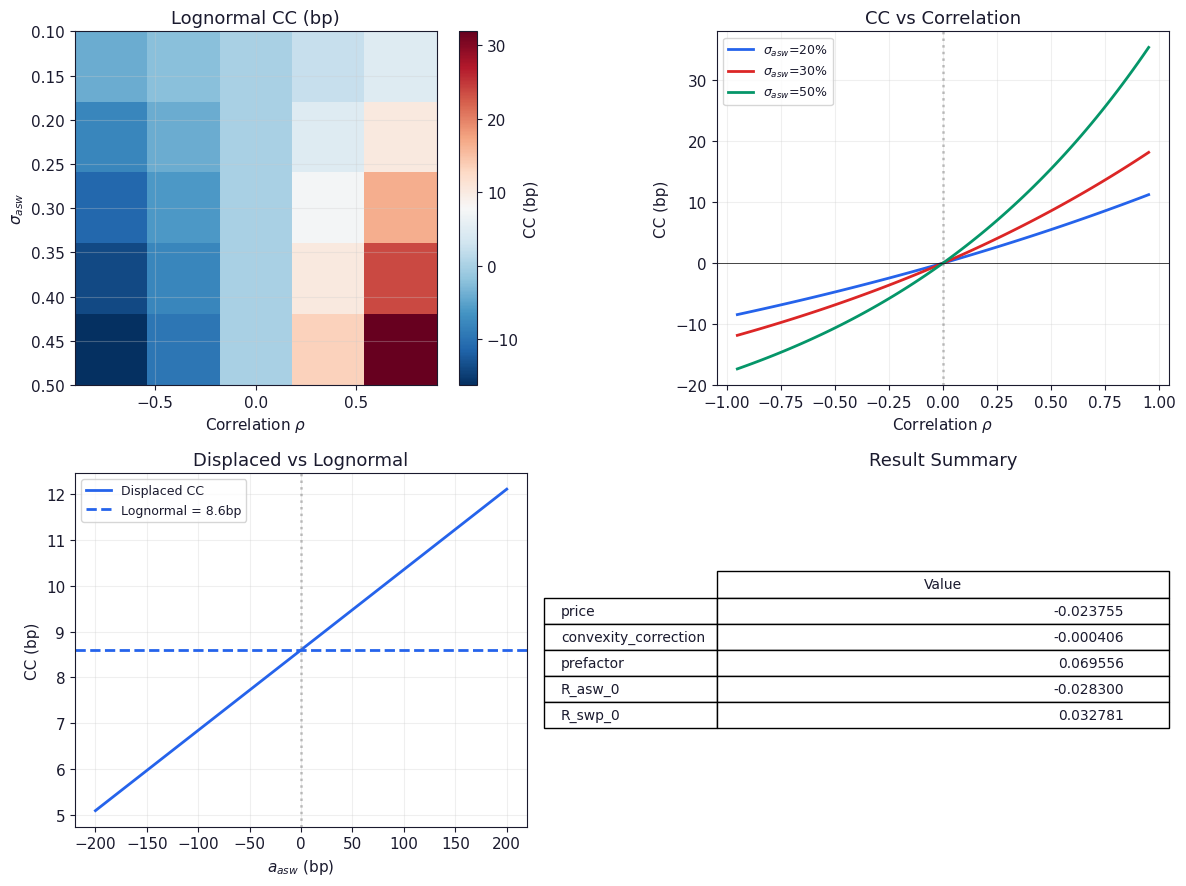

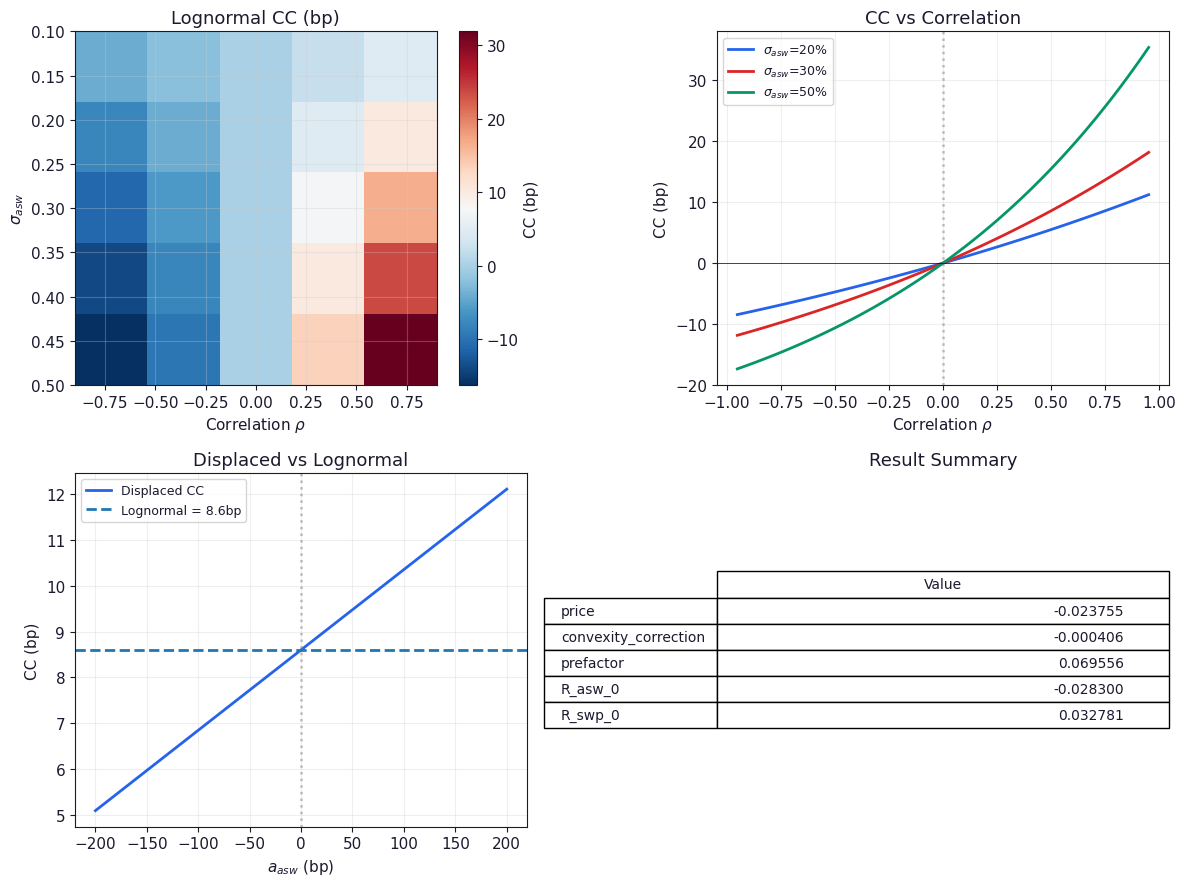

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "python"))

from datetime import date, timedelta
from pricebook.bootstrap import bootstrap
from pricebook.cmasw import CMASWInstrument
from pricebook.viz import plot, PlotBuilder

REF = date(2026, 4, 26)
deposits = [(REF + timedelta(days=91), 0.04), (REF + timedelta(days=182), 0.039)]
swaps = [(REF + timedelta(days=365), 0.038), (REF + timedelta(days=1825), 0.035),
         (REF + timedelta(days=3650), 0.034)]
curve = bootstrap(REF, deposits, swaps)

cmasw = CMASWInstrument(
    REF + timedelta(days=1825), REF + timedelta(days=2007),
    swap_tenor=5, bond_price=0.95, sigma_swp=0.30, sigma_asw=0.25, rho=0.5)

# Default dashboard
plot(cmasw, curve)

## 1. Lognormal CC Heatmap (Paper Table 2)

$\text{CC} = R_0^{asw} \left(1 - \frac{A_0 \alpha}{D_{0,T_p}}\right) \left(e^{\sigma_{swp}\sigma_{asw}\rho T_0} - 1\right)$

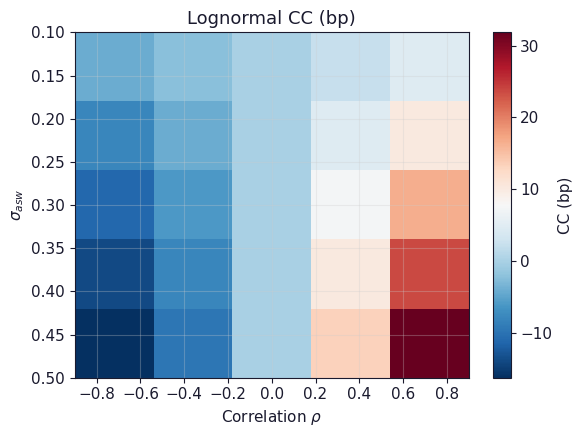

In [2]:
# CC heatmap (sigma_asw x rho)
PlotBuilder(cmasw, curve).heatmap().figure()

## 2. CC as Function of Correlation

CC has the sign of $\rho$ in the lognormal case. Linear in $\rho$ to first order.

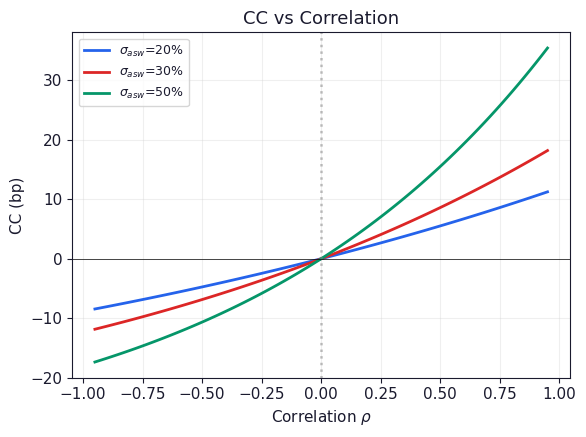

In [3]:
# CC vs rho
PlotBuilder(cmasw, curve).payoff().figure()

## 3. Displaced vs Lognormal: Skew Impact

Displacement $a_{asw}$ controls the ATM skew. Small displacement $\Rightarrow$ small deviation from lognormal CC.

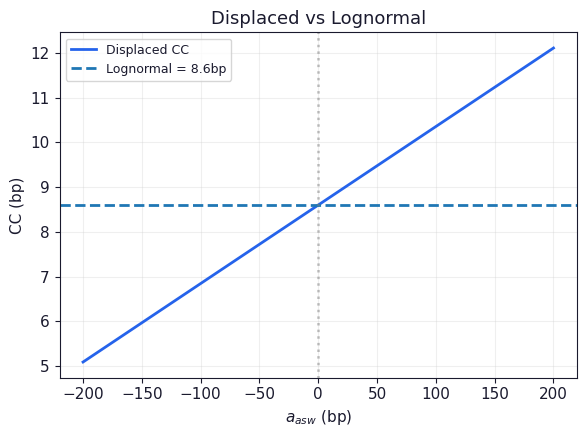

In [4]:
# Displaced vs lognormal
PlotBuilder(cmasw, curve).comparison().figure()